# Week 6: Transformer Attention and Rotary Position Encoding

This notebook builds attention from scratch, contrasts traditional positional encoding with rotary positional encoding (`RoPE`), and assembles a reusable Transformer block with both self-attention and cross-attention.

## Learning Goals
- Understand scaled dot-product attention and the role of `Query`, `Key`, and `Value`.
- Compare traditional additive positional encoding with rotary positional encoding.
- Build a Transformer block with residual connections, layer normalization, self-attention, and feed-forward layers.
- Extend the same block with cross-attention.
- Visualize attention weights in color so we can inspect where information flows.
- Reuse the saved IMDb tokenized dataset for a small Transformer encoder classifier setup.

## Reused Assets and Small Demo Data
This week reuses the saved IMDb tokenized assets from the previous weeks so the modeling comparison stays consistent.

- `../week3-embedding/datasets/imdb_bpe_dataset.pt`
- `../week3-embedding/datasets/bpe_vocab.json`
- `../week3-embedding/datasets/bpe_merges.json`
- `../week3-embedding/models/vocab_config.json`

For cross-attention, we also use a tiny IMDb-style paired-text probe. Each hand-written record looks like a miniature review example with a review snippet, sentiment label, and a question that attends back to the review evidence. This keeps the demo small while making the data shape feel closer to the IMDb sentiment work from earlier weeks.

## Suggested Concepts Flow
- **Concept 1:** Build intuition for scaled dot-product self-attention and inspect a heatmap.
- **Concept 2:** Compare traditional positional encoding with rotary positional encoding (`RoPE`).
- **Concept 3:** Assemble a Transformer block with residual connections, layer norm, and feed-forward layers.
- **Concept 4:** Add cross-attention and test it on a tiny IMDb-style paired-text probe.
- **Concept 5:** Reuse the same components for a compact IMDb Transformer encoder classifier.

You can treat each concept as one notebook checkpoint instead of trying to finish the full notebook in one sitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

from utils import (
    MultiHeadAttention,
    TinyTransformerClassifier,
    TransformerBlock,
    bpe_batch_encode,
    apply_rope,
    build_rope,
    evaluate_binary_classifier,
    get_device,
    load_json,
    plot_attention_heads,
    plot_attention_heatmap,
    scaled_dot_product_attention,
    sinusoidal_position_encoding,
    train_binary_classifier,
    clean_memory
)


In [2]:
train_ds = torch.load("../week3-embedding/datasets/train_ds.pt", weights_only=False)
val_ds = torch.load("../week3-embedding/datasets/val_ds.pt", weights_only=False)
test_ds = torch.load("../week3-embedding/datasets/test_ds.pt", weights_only=False)

bpe_vocab = load_json("../week3-embedding/datasets/bpe_vocab.json")
bpe_merges = load_json("../week3-embedding/datasets/bpe_merges.json")
vocab_config = load_json("../week3-embedding/models/vocab_config.json")

id_to_token = {idx: token for token, idx in bpe_vocab.items()}
vocab_size = vocab_config["vocab_size"]
pad_id = vocab_config["pad_id"]
device = get_device()

print("device:", device)
print("vocab size:", vocab_size)
print("pad id:", pad_id)


device: mps
vocab size: 590
pad id: 589


In [3]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

train: 40000 | val: 5000 | test: 5000


## Concept 1: Attention Foundations
The goal for Concept 1 is to understand what attention is doing mechanically before we add position information or stack multiple sublayers.

### Self-Attention Intuition
A self-attention layer lets each token build a weighted summary of the other tokens in the same sequence. The weights come from similarity between `query` and `key`, while the content being aggregated comes from `value`. In matrix form, scaled dot-product self-attention is

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

where `Q`, `K`, and `V` all come from the same token sequence in the self-attention case.

For the first demo, we reuse the learned Week 3 `DAN` embedding weights so the token representations are not random. We also start with a projection-free version where `Q = K = V = token states` and call `scaled_dot_product_attention` directly, because the attention heatmap should visualize the attention weights themselves before we add learned projection layers in later cells.

This first visualization uses a single attention head only. We do not split the `384`-dimensional token state into multiple heads yet, so the extra head axis in the tensor shape is just a size-1 placeholder to match the attention function API. Multi-head splitting comes later.

This first self-attention demo also has no positional information at all. The attention scores depend only on content similarity between token vectors, not on token order or distance, which is exactly why we need positional encoding in the next section.

Because this demo does not use trained `Q`, `K`, or `V` projection layers, the attention scores are based directly on similarities between the fixed Week 3 token embeddings. In that sense, this first heatmap is mostly showing scaled static embedding similarity, not a learned attention pattern.

One easy-to-miss detail: even when a token is compared with itself, its final attention weight is not automatically `1`. Scaling divides every score in the row by the same `sqrt(d)` factor, and then softmax normalizes that token's self-score together with all of its scores against the other tokens. So a diagonal entry is only close to `1` if that self-score is much larger than the rest of the row.

Masking has two steps in our implementation. First, masked score positions are filled with `torch.finfo(dtype).min` before softmax so they should receive essentially zero probability. Then we apply the mask again after softmax, explicitly setting masked attention weights to `0.0`. This second mask is a defensive cleanup: with finite-precision arithmetic, fully masked or extreme rows can sometimes produce tiny nonzero values or unstable values after softmax, so double masking keeps padded or disallowed positions from contributing to the value-weighted sum.

Important caution: even with a learned embedding matrix, this is still not a trained attention layer. The displayed attention weights come from raw dot products on the current token states, so the heatmap is useful for understanding the mechanics of scaling, masking, and weighted averaging, but it should not be trusted as a meaningful explanation of what the model has learned. Once we introduce random `Q`, `K`, and `V` projection layers later, the heatmap becomes even less semantically interpretable until training has happened.

When the same sequence produces `Q`, `K`, and `V`, we call it **self-attention**.


sample tokens: ['The</w>', 'b', 'oo', 'k</w>', 'is</w>', 'gre', 'at</w>', '.</w>', 'It</w>', "'</w>", 's</w>', 'one</w>']
token states: (1, 12, 384)
query shape: (1, 1, 12, 384)
key shape: (1, 1, 12, 384)
value shape: (1, 1, 12, 384)
attention scores: (1, 1, 12, 12)
attention weights: (1, 1, 12, 12)
attention output: (1, 1, 12, 384)
head 0, first query weights: tensor([0.9504, 0.0045, 0.0043, 0.0053, 0.0064, 0.0028, 0.0034, 0.0016, 0.0030,
        0.0034, 0.0061, 0.0087])


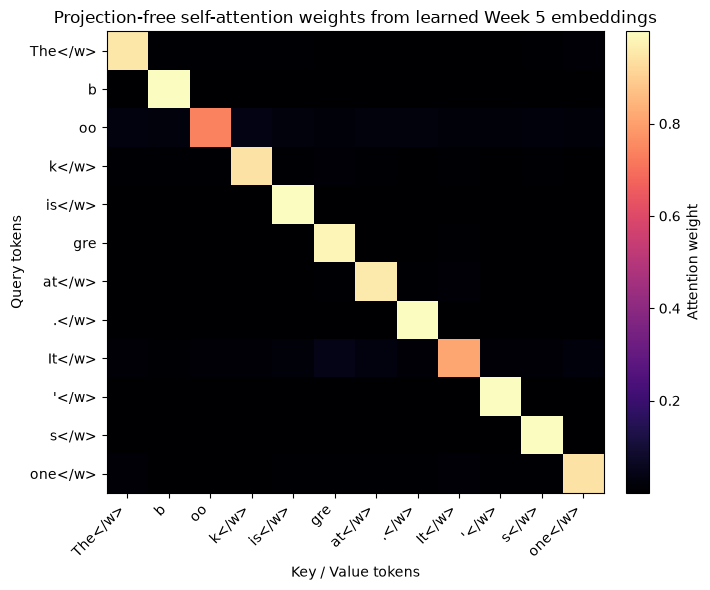

In [4]:
embedding_layer = torch.load("../week3-embedding/models/imdb_embedding_layer.pt", map_location=device, weights_only=True)
embedding_weight = embedding_layer["weight"].to(device)
embedding_dim = embedding_weight.size(1)
embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)

# Pick one real IMDb example and trim to a short non-pad prefix for visualization.
batch_input_ids, batch_masks, batch_labels = next(iter(train_loader))
sample_index = 17
sample_length = int(batch_masks[sample_index].sum().item())
display_len = min(12, sample_length)
sample_ids = batch_input_ids[sample_index : sample_index + 1, :display_len].to(device)
sample_mask = batch_masks[sample_index : sample_index + 1, :display_len].to(device)
sample_tokens = [id_to_token[token_id] for token_id in sample_ids[0].tolist()]

token_states = embedding_weight[sample_ids]
query = token_states.unsqueeze(1)
key = token_states.unsqueeze(1)
value = token_states.unsqueeze(1)
attention_mask = sample_mask.to(dtype=torch.bool).unsqueeze(1).unsqueeze(1)

attention_output, attention_weights = scaled_dot_product_attention(
    query=query,
    key=key,
    value=value,
    attention_mask=attention_mask,
    dropout_p=0.0,
    training=False,
)

score_scale = embedding_dim ** -0.5
attention_scores = torch.matmul(query, key.transpose(-2, -1)) * score_scale
attention_scores = attention_scores.masked_fill(~attention_mask, torch.finfo(attention_scores.dtype).min)

print("sample tokens:", sample_tokens)
print("token states:", tuple(token_states.shape))
print("query shape:", tuple(query.shape))
print("key shape:", tuple(key.shape))
print("value shape:", tuple(value.shape))
print("attention scores:", tuple(attention_scores.shape))
print("attention weights:", tuple(attention_weights.shape))
print("attention output:", tuple(attention_output.shape))
print("head 0, first query weights:", attention_weights[0, 0, 0].detach().cpu())

plot_attention_heatmap(
    attention_weights,
    sample_tokens,
    key_tokens=None,
    title="Projection-free self-attention weights from learned Week 5 embeddings",
    head=0,
    batch_idx=0,
)


## Concept 2: Position Information
Now that the attention mechanism itself is clear, the next question is how the model knows token order. We start with the original additive approach and then move to rotary encoding.

### Why Position Encoding Exists
Self-attention by itself is permutation-equivariant: if we reorder the input tokens and apply the same reordering to the outputs, the attention computation is unchanged. So without positional information, token order is invisible to the model. Position encoding is what breaks that symmetry so the model can learn order-sensitive patterns such as negation scope, phrase structure, and long-range dependencies.

It is useful to compare this with earlier architectures:
- `RNN`s have sequential order baked in because hidden state is updated token by token.
- `CNN`s get locality from finite convolution windows, but not a full notion of arbitrary sequence position unless we add something else.
- plain self-attention sees all tokens at once, but without PE it only sees content similarity.

There is also a helpful mathematical intuition for sinusoidal encodings. For one frequency $\omega$, using paired sine and cosine coordinates means two positions interact through identities like

$$
\sin(\omega p_1)\sin(\omega p_2) + \cos(\omega p_1)\cos(\omega p_2) = \cos(\omega (p_1 - p_2))
$$

So the dot product between two positional vectors naturally depends on their relative offset. Another way to say this is that there is a fixed linear transformation `R(k)` such that shifting a position by `k` steps corresponds to a deterministic rotation:

$$
PE(pos + k) = R(k) \; PE(pos)
$$

That gives the model a reusable way to reason about positional shifts, even before we learn any task-specific attention projections.


### Traditional Positional Encoding
The original Transformer adds a position vector to the token embedding once near the input. This lets the model know where a token is, but the positional information is injected additively rather than directly modifying the attention geometry in every block.

The sinusoidal positional encoding used in the original paper is

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right), \qquad
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

where `pos` is the token position and `i` indexes pairs of embedding dimensions. The full input to the model is then formed by adding token embeddings and positional encodings:

$$
x_{pos} = e_{pos} + PE(pos)
$$

There is also a useful intuition behind the even/odd pairing of sine and cosine. Because

$$
\cos(A-B) = \cos A \cos B + \sin A \sin B
$$

a model can combine the sine and cosine coordinates from two positions to reason about relative offsets between them. This is one reason sinusoidal encodings can support position comparisons without learning a separate table of position embeddings.

Another design detail is that the early embedding dimensions oscillate quickly while the later ones oscillate much more slowly. That happens because the denominator `10000^{2i / d_{model}}` grows with `i`, so higher dimensions change more gradually across positions. The result is a bank of waves at different frequencies: some capture fine local shifts and others capture broader position patterns.

Because these values are deterministic, we can precompute and cache them once for a chosen maximum sequence length and then reuse them across batches, which makes inference and training cheaper. But that convenience also exposes a limitation: the encoding is defined only up to the maximum cached length, so it can become a hard context-window constraint unless we rebuild or extend the cache.

A second limitation is architectural rather than computational. This positional information is injected only once near the input by addition, so after many Transformer blocks the model has to preserve that signal indirectly inside its hidden states. In practice that means the original positional signal can become diluted or harder to recover compared with methods like RoPE that reintroduce position structure directly inside every attention computation.


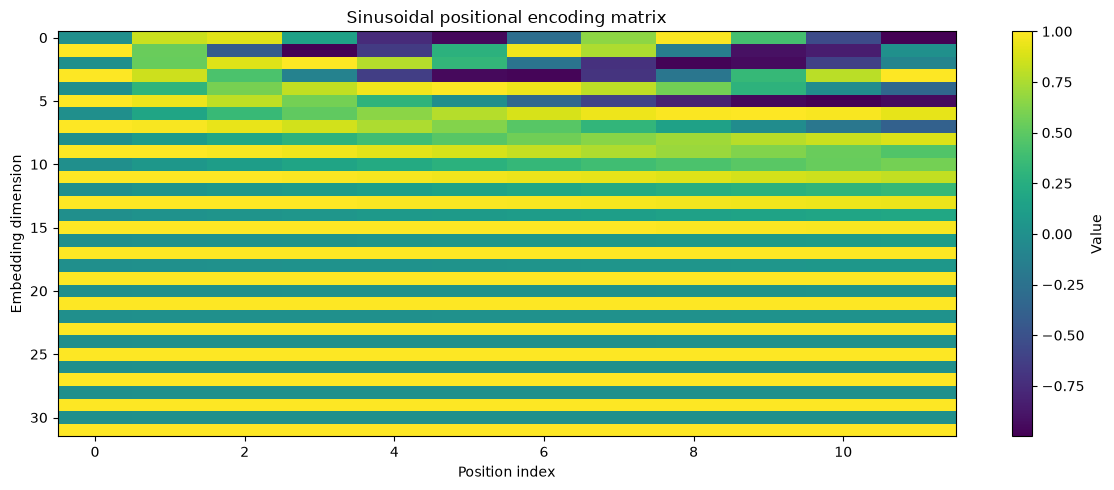

In [5]:
pe = sinusoidal_position_encoding(seq_len=12, d_model=32)

plt.figure(figsize=(12, 5))
plt.imshow(pe.T, aspect="auto", cmap="viridis")
plt.colorbar(label="Value")
plt.xlabel("Position index")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal positional encoding matrix")
plt.tight_layout()
plt.show()

### Rotary Positional Encoding (`RoPE`)
`RoPE` rotates pairs of dimensions inside the query and key vectors. This means position is injected inside the attention calculation itself rather than only once after the embedding layer.

For each position `p` and frequency index `i`, RoPE uses an angle

$$
\theta_{p,i} = p \cdot 10000^{-2i / d}
$$

and rotates each 2D pair of coordinates according to

$$
\begin{bmatrix}
x_{2i}^{\prime} \\ 
x_{2i+1}^{\prime}
\end{bmatrix}
=
\begin{bmatrix}
\cos \theta_{p,i} & -\sin \theta_{p,i} \\ 
\sin \theta_{p,i} & \cos \theta_{p,i}
\end{bmatrix}
\begin{bmatrix}
x_{2i} \\ 
x_{2i+1}
\end{bmatrix}
$$

In the notebook code, this is implemented with

$$
\mathrm{RoPE}(x) = x \odot \cos(\theta) + \mathrm{rotate\_half}(x) \odot \sin(\theta)
$$

That rotation is useful because it preserves vector magnitudes and angles within each 2D subspace while making dot products depend on relative offsets between positions. This is one reason rotary encoding is widely used in modern Transformer and LLM architectures.


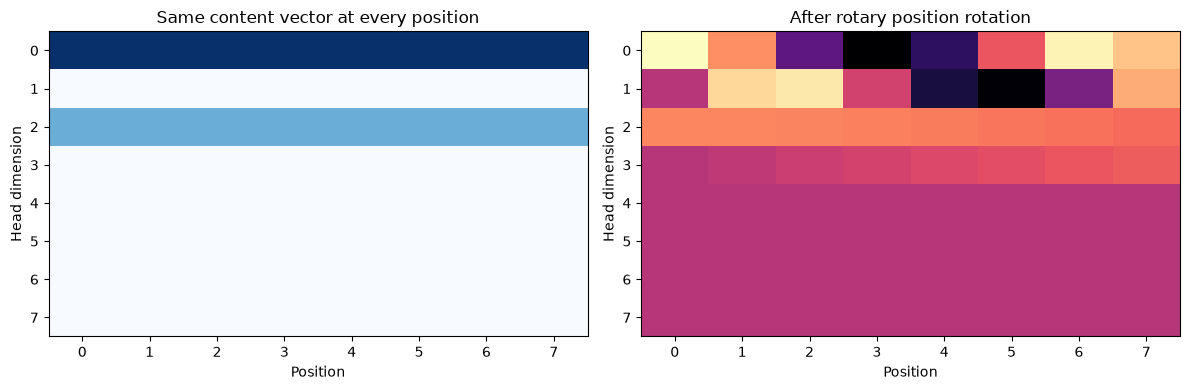

In [6]:
base_vector = torch.zeros(1, 1, 8, 8)
base_vector[..., 0] = 1.0
base_vector[..., 2] = 0.5

cos, sin = build_rope(seq_len=8, head_dim=8)
rotated = apply_rope(base_vector, cos, sin)[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(base_vector[0, 0].T, aspect="auto", cmap="Blues")
axes[0].set_title("Same content vector at every position")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Head dimension")

axes[1].imshow(rotated.T, aspect="auto", cmap="magma")
axes[1].set_title("After rotary position rotation")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Head dimension")

plt.tight_layout()
plt.show()


### Why RoPE Changes The Story
RoPE changes positional handling in a more structural way than additive sinusoidal PE. Instead of adding one positional vector at the input and hoping later layers preserve it, RoPE rotates `Q` and `K` inside every attention layer. That means positional structure is re-injected at each block rather than only once.

For dimension pair `i` at position `p`, the rotation angle is

$$
\theta_{p,i} = p \cdot 10000^{-2i/d}
$$

and each pair is rotated as

$$
[x_0^\prime, x_1^\prime] = [x_0 \cos \theta - x_1 \sin \theta, \; x_0 \sin \theta + x_1 \cos \theta]
$$

In code we usually do not materialize an explicit $2 \times 2$ matrix. We use the efficient identity

$$
\mathrm{RoPE}(x) = x \odot \cos(\theta) + \mathrm{rotate\_half}(x) \odot \sin(\theta)
$$

where `rotate_half` swaps even/odd coordinates and flips signs so the off-diagonal rotation terms appear element-wise. Also note that `V` is not rotated: `V` is content to be aggregated, while position should mainly affect which tokens attend to which other tokens through `QK^T`.

The key inductive bias is that the dot product between rotated vectors depends on relative offset:

$$
\mathrm{RoPE}(q, p) \cdot \mathrm{RoPE}(k, m) = f(q, k, p - m)
$$

So attention scores become functions of content and relative distance, not just absolute positions. As `|p-m|` grows, the rotations become increasingly misaligned, which often leads to a softer long-range decay in similarity and gives the model an inductive bias toward attending more strongly to nearby tokens.


### Position Encoding, Context Windows, And Memory
The usable context window of a Transformer is usually co-determined by at least three things: positional out-of-distribution behavior, the `O(n^2)` cost of attention, and whether training data actually exposed the model to long-range dependencies. Position encoding is only one part of that story, but it is often a binding constraint.

For traditional sinusoidal PE, the cache is a fixed lookup table. That is convenient because we can precompute and reuse it, but positions beyond `max_seq_len` have no entries unless we rebuild the cache, and those longer positions are out-of-distribution relative to training. Sinusoidal PE is also injected only once at the input, so across many attention and feed-forward blocks the original positional signal can become diluted. It also encodes absolute position: position `500` looks like the same absolute coordinate regardless of whether the full sequence length is `512` or `8192`.

> **Note on RoPE Efficiency:** In our teaching implementation, `build_rope` is called dynamically on every forward pass inside `MultiHeadAttention`. While functionally correct, this is computationally wasteful. In production models, RoPE caches are also precomputed once (like sinusoidal PE) into a buffer sized to `max_seq_len` and then sliced per batch, rather than being freshly generated per-block at every step.


RoPE has softer failure behavior, but it is not magic. Beyond the training length, both sinusoidal PE and RoPE face positional OOD issues. RoPE often generalizes better because nearby relative offsets remain well-behaved even when the absolute index grows, but long-context quality is still limited by what the model was trained to use. This is why changing only the positional scheme, such as with interpolation or scaling methods, can sometimes unlock longer context without full retraining: it shows the positional OOD issue was the bottleneck.

Common context-extension ideas include:
- `Position Interpolation`: compress all positions into the trained range. This is cheap, but can blur local attention geometry.
- `NTK-aware scaling`: increase the RoPE base beyond `10000` to stretch wavelengths while preserving more local detail.
- `YaRN`: treat different frequency bands differently so some are interpolated, some preserved, and some extrapolated.
- `LongRoPE` and related methods: apply non-uniform per-dimension rescaling to push context much further.

A useful high-level mental model is: positional encoding does not directly give a model better memory. It gives the model better routing tools for distance-sensitive attention decisions. Whether the model actually uses those tools well depends on training. RoPE's long-term decay is a helpful inductive bias, but it does not by itself solve forgetting.

This is also separate from the classic `lost in the middle` problem. That phenomenon is not just a positional-encoding bug: many models over-weight the beginning and end of a sequence even when positional handling is improved. Modern mitigations are usually training or systems-level fixes, such as needle-in-a-haystack training, retrieval-augmented generation, chunked or sliding-window attention, or even alternative sequence models like `Mamba` and `RWKV`. It is still an active research problem.


## Concept 3: Building the Transformer Block
With attention and position handling in place, we can package the pieces into the standard block structure used throughout encoder and decoder stacks.

### Residual Connections and the Transformer Block
A Transformer block packages together self-attention, residual connections, normalization, and a feed-forward update. At a high level, the block first lets each token gather information from other tokens through attention, then refines that result with an MLP-style feed-forward network. Residual connections make both updates additive instead of replacing the old representation completely.

This notebook uses a **pre-norm** Transformer block. That means LayerNorm is applied before each sublayer, then the sublayer output is added back to the residual stream. In simplified form, the self-attention-only block is

- `x = x + self_attention(layer_norm(x))`
- `x = x + feed_forward(layer_norm(x))`

For the cross-attention variant, the same idea extends to the extra cross-attention sublayer:

- `x = x + self_attention(layer_norm(x))`
- `x = x + cross_attention(layer_norm(x), context)`
- `x = x + feed_forward(layer_norm(x))`

This is different from a post-norm block, where LayerNorm would be applied after the residual addition. Pre-norm blocks are common in modern implementations because they usually make deeper Transformer stacks easier to optimize.

Transformers also rely on LayerNorm to keep hidden-state scales stable. The exact LayerNorm formula is

$$
\mathrm{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

where $\mu$ and $\sigma^2$ are computed across the hidden dimensions of one token representation, and $\gamma$ and $\beta$ are learned scale and shift parameters. It is better to write LayerNorm this way than as division by $\mathrm{std}(x)$ because implementations explicitly normalize by $\sqrt{\sigma^2 + \epsilon}$ for numerical stability.

LayerNorm is used in Transformers because each token can be normalized independently, without depending on the rest of the batch. That makes it much more natural than BatchNorm for variable-length sequences, masking, and autoregressive inference. BatchNorm mixes statistics across different examples or token positions in the batch, which creates an unnatural coupling between tokens that may appear at the same position index but have completely different meanings or context.

The feed-forward part of the block often uses GeLU rather than ReLU. ReLU is

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

so every negative value is clamped to exactly zero. GeLU is

$$
\mathrm{GeLU}(x) = x \Phi(x)
$$

where $\Phi(x)$ is the standard Gaussian CDF. Unlike ReLU, GeLU does not hard-cut all negative inputs to zero; mildly negative values can survive with small magnitude. That smoother gating is one reason GeLU is common in modern Transformers.

In PyTorch, `nn.GELU` defaults to `approximate="none"`, which uses the exact formulation rather than the tanh approximation. You can explicitly request the common fast approximation with `nn.GELU(approximate="tanh")`, which uses

$$
\mathrm{GeLU}(x) \approx 0.5x\left(1 + \tanh\left(\sqrt{2 / \pi}(x + 0.044715x^3)\right)\right)
$$

This notebook keeps the default `nn.GELU()` behavior.

This helps optimization and preserves useful information from earlier layers. To keep the setup consistent with the earlier weeks, we feed the block with the learned Week 3 embedding matrix rather than a new random embedding layer. That also means `d_model` should match the embedding width exactly, which here is `384`.

For inspection, it helps to look at two things together:
- the self-attention map: which tokens route information to which other tokens
- the per-token update size: how much each token representation changed from input to output

For one token position `t`, we measure that update size with the L2 norm

$$
\Delta_t = \lVert x_t^{\text{out}} - x_t^{\text{in}} \rVert_2
$$

A larger $\Delta_t$ means the block changed that token's representation more strongly. A smaller $\Delta_t$ means the block left it closer to its original hidden state.

Important caution: this block is still untrained in the notebook demo. So the attention maps and update norms are useful for understanding the mechanics of the architecture, but they should not be interpreted as meaningful learned linguistic behavior yet.


d_model: 384
embedded batch: (2, 96, 384)
block output: (2, 96, 384)
self-attention tensor: (2, 4, 96, 96)
example tokens: ['i</w>', 'just</w>', 'sa', 'w</w>', 'D', 'ic', 'k</w>', 'T', 'r', 'ac', 'y</w>', 'and</w>']
token update norms: tensor([4.0101, 4.2617, 4.1772, 3.8956, 4.2391, 3.7765, 3.6387, 4.3335, 4.3002,
        3.7166, 3.9217, 3.8878])


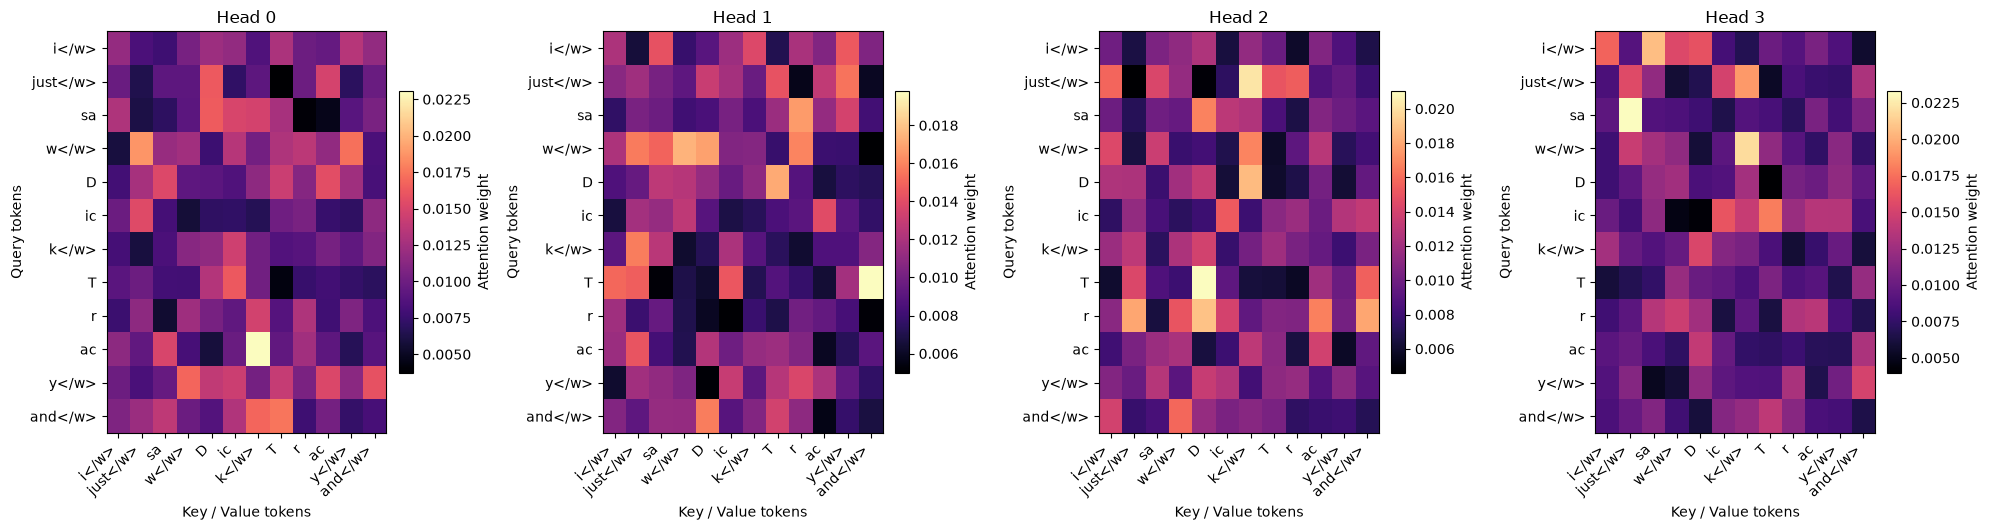

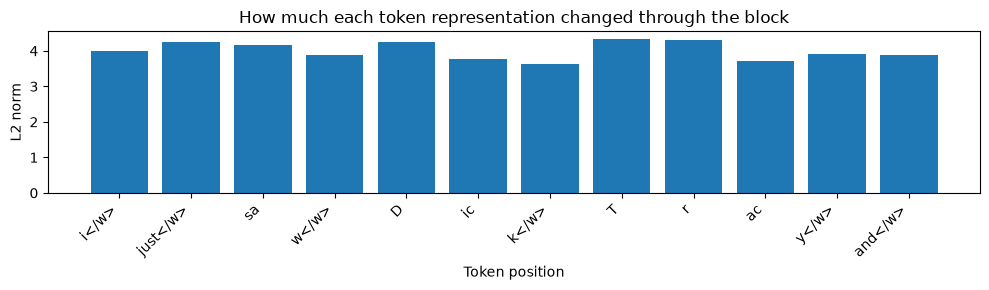

In [7]:
batch_size = 2
seq_len = 96
d_model = embedding_weight.size(1)
num_heads = 4

sample_ids = batch_input_ids[:batch_size, :seq_len].to(device)
sample_masks = batch_masks[:batch_size, :seq_len].to(device)

sample_states = embedding_weight[sample_ids]

transformer_block = TransformerBlock(
    d_model=d_model,
    num_heads=num_heads,
    mlp_hidden_dim=4 * d_model,
    dropout=0.0,
    use_rope=True,
    enable_cross_attention=False,
).to(device)

block_output, block_attentions = transformer_block(
    x=sample_states,
    attention_mask=sample_masks,
    return_attentions=True,
)

example_idx = 1
valid_len = int(sample_masks[example_idx].sum().item())
display_len = min(12, valid_len)
example_tokens = [id_to_token[int(token_id)] for token_id in sample_ids[example_idx, :display_len].tolist()]

example_attention = block_attentions["self_attention"][example_idx:example_idx + 1, :, :display_len, :display_len].detach().cpu()
example_input = sample_states[example_idx, :display_len].detach().cpu()
example_output = block_output[example_idx, :display_len].detach().cpu()
delta_norm = (example_output - example_input).norm(dim=-1)

print("d_model:", d_model)
print("embedded batch:", tuple(sample_states.shape))
print("block output:", tuple(block_output.shape))
print("self-attention tensor:", tuple(block_attentions["self_attention"].shape))
print("example tokens:", example_tokens)
print("token update norms:", delta_norm)

plot_attention_heads(
    example_attention,
    query_tokens=example_tokens,
    key_tokens=None,
    max_heads=4,
    batch_idx=0,
)

plt.figure(figsize=(10, 3))
plt.bar(range(display_len), delta_norm.numpy())
plt.xticks(range(display_len), example_tokens, rotation=45, ha="right")
plt.ylabel("L2 norm")
plt.xlabel("Token position")
plt.title("How much each token representation changed through the block")
plt.tight_layout()
plt.show()


## Concept 4: Cross-Attention with a Tiny Probe
Cross-attention needs two sequences with different roles: one sequence provides information, and the other sequence asks what to focus on. IMDb is not naturally paired text, so we make a tiny IMDb-style probe by pairing short review snippets with evidence-seeking queries.

### Tiny IMDb-Style Paired-Text Probe for Cross-Attention
IMDb is naturally a single-sequence classification dataset: a review text plus a sentiment label. For cross-attention, we create three small paired records that preserve that feel while adding a query sequence.

Unlike the first version of this probe, we encode these examples with the saved IMDb byte-level BPE vocabulary and merges from earlier weeks. That means the IDs line up with the same learned `DAN` embedding matrix used in the self-attention demos.

Each example has:
- a **review** context that provides movie-review evidence
- a **sentiment** label, like IMDb
- a **query** sequence that asks which review details matter

The query states act like decoder-side states: they attend over the encoded review states and pull out relevant evidence.

In [8]:
cross_attention_pairs = [
    {
        "title": "Midnight Harbor",
        "sentiment": "positive",
        "context": (
            "review: Midnight Harbor has warm performances and patient direction. "
            "The middle drags, but the final act is moving and satisfying."
        ),
        "query": "which review details support a positive label ?",
    },
    {
        "title": "The Glass Planet",
        "sentiment": "negative",
        "context": (
            "review: The Glass Planet looks expensive, yet the plot is thin, "
            "the jokes fall flat, and the ending feels rushed."
        ),
        "query": "which review details support a negative label ?",
    },
    {
        "title": "Borrowed Summer",
        "sentiment": "mixed",
        "context": (
            "review: Borrowed Summer is not a disaster; the cast is charming, "
            "although the script repeats scenes and loses energy."
        ),
        "query": "which phrase softens the negative review ?",
    },
]

context_ids, context_masks, context_tokens = bpe_batch_encode(
    [item["context"] for item in cross_attention_pairs],
    bpe_merges=bpe_merges,
    bpe_vocab=bpe_vocab,
    max_len=64,
)
query_ids, query_masks, query_tokens = bpe_batch_encode(
    [item["query"] for item in cross_attention_pairs],
    bpe_merges=bpe_merges,
    bpe_vocab=bpe_vocab,
    max_len=24,
)

print("tiny IMDb-style probe examples:", len(cross_attention_pairs))
for idx, item in enumerate(cross_attention_pairs):
    print(f"{idx}: {item['title']} | sentiment={item['sentiment']}")
print("context batch:", tuple(context_ids.shape))
print("query batch:", tuple(query_ids.shape))
print("IMDb BPE vocab size:", len(bpe_vocab))
print("example context BPE tokens:", context_tokens[0][: int(context_masks[0].sum().item())])
print("example query BPE tokens:", query_tokens[0][: int(query_masks[0].sum().item())])


tiny IMDb-style probe examples: 3
0: Midnight Harbor | sentiment=positive
1: The Glass Planet | sentiment=negative
2: Borrowed Summer | sentiment=mixed
context batch: (3, 64)
query batch: (3, 24)
IMDb BPE vocab size: 590
example context BPE tokens: ['re', 'vi', 'e', 'w</w>', ':</w>', 'mi', 'd', 'n', 'i', 'ght</w>', 'h', 'ar', 'b', 'or</w>', 'has</w>', 'w', 'ar', 'm</w>', 'per', 'for', 'man', 'c', 'es</w>', 'and</w>', 'p', 'a', 'ti', 'ent</w>', 'di', 're', 'c', 'tion</w>', '.</w>', 'the</w>', 'mi', 'd', 'd', 'le</w>', 'd', 'ra', 'g', 's</w>', ',</w>', 'but</w>', 'the</w>', 'fin', 'al</w>', 'ac', 't</w>', 'is</w>', 'mov', 'ing</w>', 'and</w>', 'sa', 'ti', 's', 'f', 'ying</w>', '.</w>']
example query BPE tokens: ['which</w>', 're', 'vi', 'e', 'w</w>', 'de', 'ta', 'il', 's</w>', 'su', 'pp', 'or', 't</w>', 'a</w>', 'po', 'si', 'ti', 've</w>', 'la', 'be', 'l</w>', '?</w>']


### Projection-Free Cross-Attention from DAN Embeddings
Before adding a randomly initialized attention block, we can run scaled dot-product cross-attention directly on learned IMDb `DAN` embedding vectors. This is no longer using fake semantic vectors: `Q` comes from the query BPE embeddings, while `K` and `V` come from the review-context BPE embeddings.

As with the Concept 1 projection-free self-attention demo, the heatmap shows raw learned embedding similarity. It is mechanically useful, but it is not a trained cross-attention explanation.

query states: (1, 1, 12, 384)
context states: (1, 1, 24, 384)
manual cross-attention output shape: (1, 1, 12, 384)


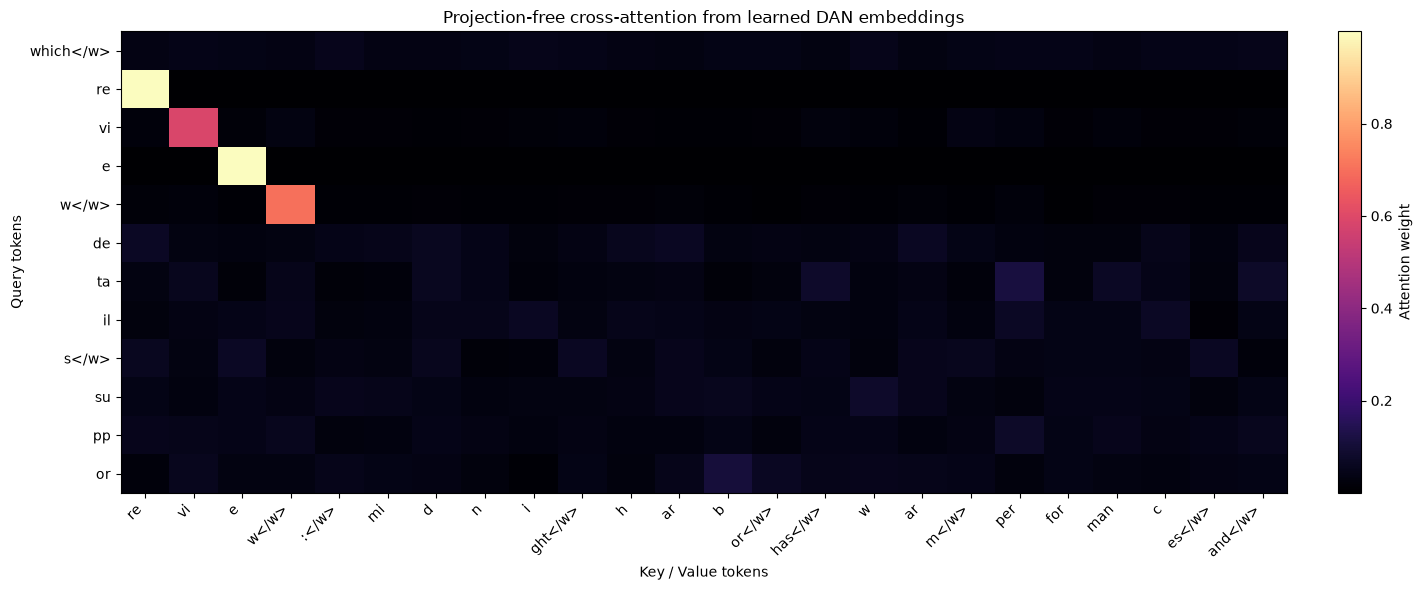

In [9]:
demo_idx = 0
demo_query_len = int(query_masks[demo_idx].sum().item())
demo_context_len = int(context_masks[demo_idx].sum().item())
display_query_len = min(12, demo_query_len)
display_context_len = min(24, demo_context_len)

demo_query_ids = query_ids[demo_idx : demo_idx + 1, :display_query_len].to(device)
demo_context_ids = context_ids[demo_idx : demo_idx + 1, :display_context_len].to(device)
demo_query_tokens = query_tokens[demo_idx][:display_query_len]
demo_context_tokens = context_tokens[demo_idx][:display_context_len]

query_states = embedding_weight[demo_query_ids].unsqueeze(1)
context_states = embedding_weight[demo_context_ids].unsqueeze(1)
context_mask = context_masks[demo_idx : demo_idx + 1, :display_context_len].to(device).bool().unsqueeze(1).unsqueeze(1)

manual_cross_output, manual_cross_attention = scaled_dot_product_attention(
    query=query_states,
    key=context_states,
    value=context_states,
    attention_mask=context_mask,
)

print("query states:", tuple(query_states.shape))
print("context states:", tuple(context_states.shape))
print("manual cross-attention output shape:", tuple(manual_cross_output.shape))
plot_attention_heatmap(
    manual_cross_attention.detach().cpu(),
    query_tokens=demo_query_tokens,
    key_tokens=demo_context_tokens,
    title="Projection-free cross-attention from learned DAN embeddings",
    head=0,
)

### Cross-Attention Block API
Now we run the reusable `TransformerBlock` in cross-attention mode using the same learned `DAN` embedding matrix. The block itself is still randomly initialized, so the attention heads below verify mechanics and tensor flow rather than learned behavior.

For this encoder-decoder-style demo, `is_causal=True` makes the query-side self-attention causal, like a decoder. Cross-attention itself is not causal: each query token can attend over the full encoded review context. We also leave RoPE out of cross-attention, because mixing decoder query positions with encoder context positions is less intuitive for this probe; positional structure is handled inside the query self-attention path instead.

d_model: 384
context states: (3, 64, 384)
query states: (3, 24, 384)
cross output shape: (3, 24, 384)
self-attention on query shape: (3, 4, 24, 24)
cross-attention shape: (3, 4, 24, 64)
decoder self-attention is causal: True
cross-attention uses RoPE: False
example query tokens: ['which</w>', 're', 'vi', 'e', 'w</w>', 'de', 'ta', 'il', 's</w>', 'su', 'pp', 'or']


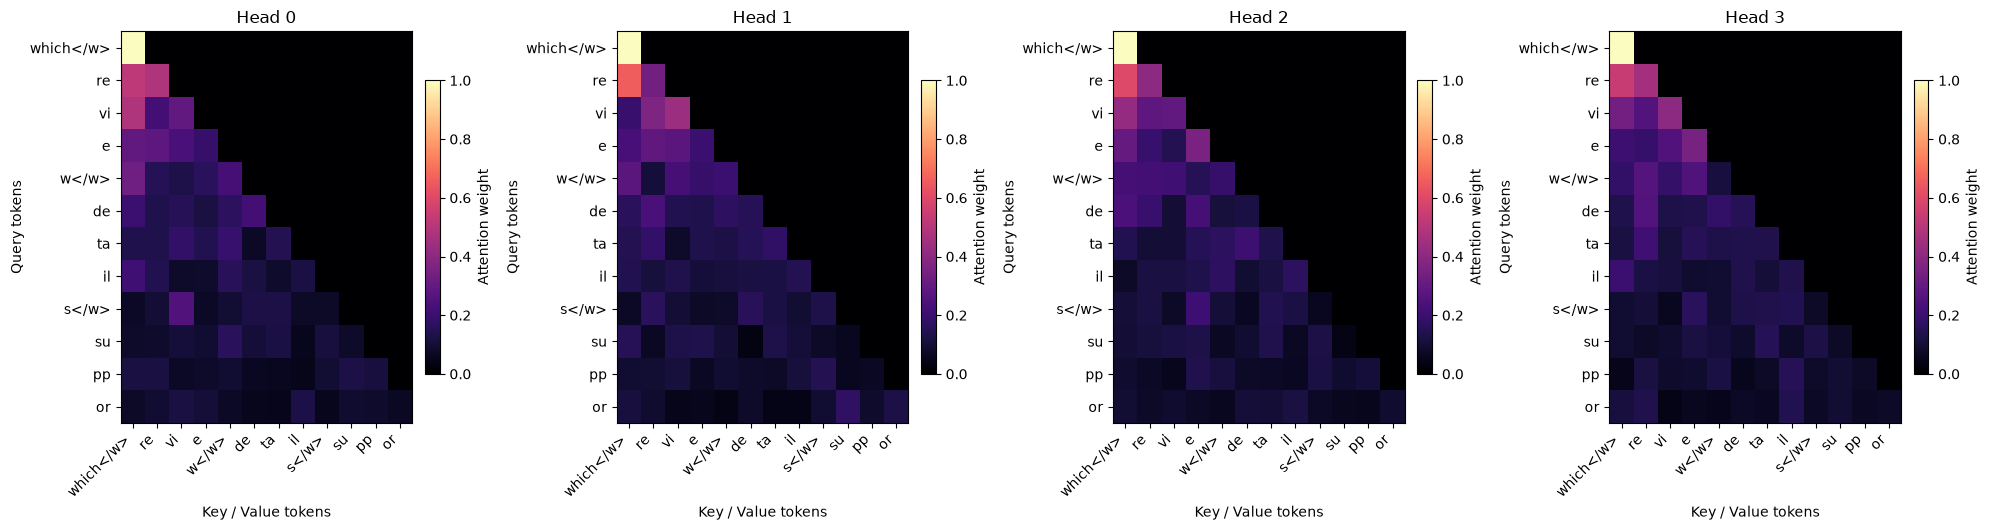

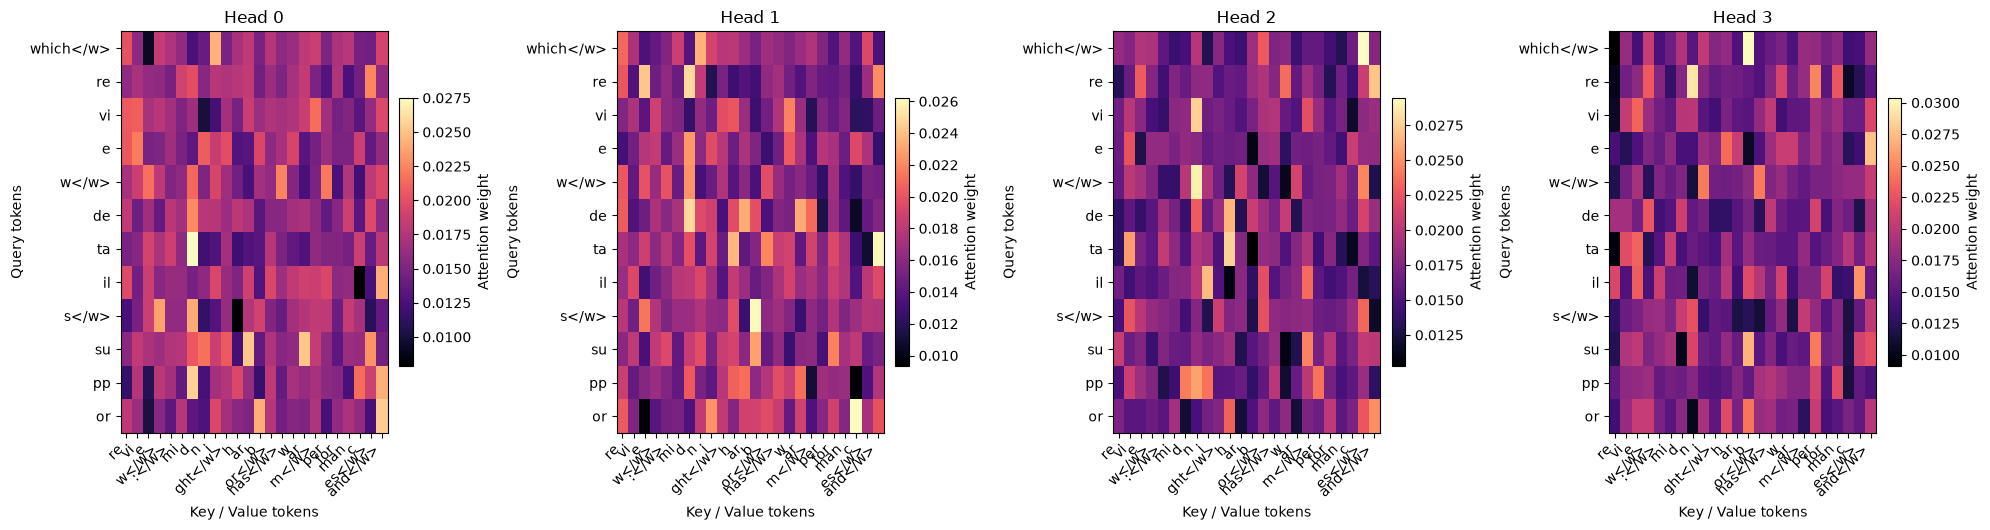

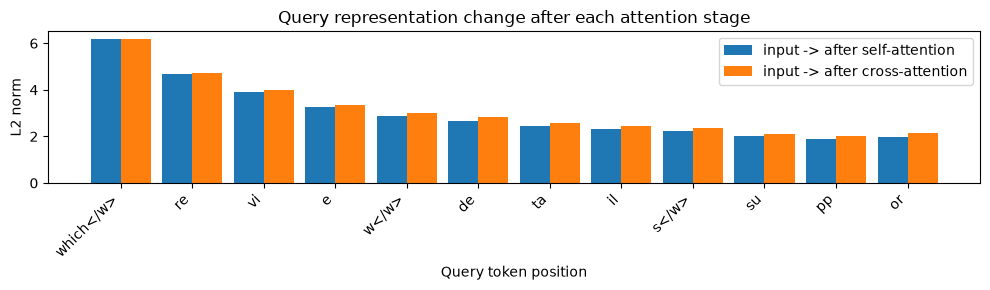

In [10]:
torch.manual_seed(11)

d_model = embedding_weight.size(1)
num_heads = 4
context_states = embedding_weight[context_ids.to(device)]
query_states = embedding_weight[query_ids.to(device)]

cross_block = TransformerBlock(
    d_model=d_model,
    num_heads=num_heads,
    mlp_hidden_dim=4 * d_model,
    dropout=0.0,
    use_rope=True,
    enable_cross_attention=True,
    is_causal=True,
).to(device)

cross_output, cross_attentions = cross_block(
    x=query_states,
    attention_mask=query_masks.to(device),
    context=context_states,
    context_mask=context_masks.to(device),
    return_attentions=True,
)

# Re-run the two attention sublayers directly so we can measure stage-by-stage deltas.
self_attn_input = cross_block.self_attn_norm(query_states)
self_attn_output = cross_block.self_attn(
    x=self_attn_input,
    attention_mask=query_masks.to(device),
    return_attention=False,
)
after_self_attention = query_states + self_attn_output

cross_attn_input = cross_block.cross_attn_norm(after_self_attention)
cross_attn_output = cross_block.cross_attn(
    x=cross_attn_input,
    attention_mask=None,
    context=context_states,
    context_mask=context_masks.to(device),
    return_attention=False,
)
after_cross_attention = after_self_attention + cross_attn_output

example_idx = 0
valid_q = int(query_masks[example_idx].sum().item())
valid_k = int(context_masks[example_idx].sum().item())
display_q = min(12, valid_q)
display_k = min(24, valid_k)
example_query_tokens = query_tokens[example_idx][:display_q]
example_context_tokens = context_tokens[example_idx][:display_k]
example_self_attention = cross_attentions["self_attention"][example_idx:example_idx + 1, :, :display_q, :display_q].detach().cpu()
example_cross_attention = cross_attentions["cross_attention"][example_idx:example_idx + 1, :, :display_q, :display_k].detach().cpu()

example_input = query_states[example_idx, :display_q].detach().cpu()
example_after_self = after_self_attention[example_idx, :display_q].detach().cpu()
example_after_cross = after_cross_attention[example_idx, :display_q].detach().cpu()
self_delta_norm = (example_after_self - example_input).norm(dim=-1)
cross_delta_norm = (example_after_cross - example_input).norm(dim=-1)

print("d_model:", d_model)
print("context states:", tuple(context_states.shape))
print("query states:", tuple(query_states.shape))
print("cross output shape:", tuple(cross_output.shape))
print("self-attention on query shape:", tuple(cross_attentions["self_attention"].shape))
print("cross-attention shape:", tuple(cross_attentions["cross_attention"].shape))
print("decoder self-attention is causal:", cross_block.self_attn.is_causal)
print("cross-attention uses RoPE:", cross_block.cross_attn.use_rope)
print("example query tokens:", example_query_tokens)

plot_attention_heads(
    example_self_attention,
    query_tokens=example_query_tokens,
    key_tokens=None,
    max_heads=4,
    batch_idx=0,
)

plot_attention_heads(
    example_cross_attention,
    query_tokens=example_query_tokens,
    key_tokens=example_context_tokens,
    max_heads=4,
    batch_idx=0,
)

x_positions = torch.arange(display_q).numpy()
bar_width = 0.42

plt.figure(figsize=(10, 3))
plt.bar(x_positions - bar_width / 2, self_delta_norm.numpy(), width=bar_width, label="input -> after self-attention")
plt.bar(x_positions + bar_width / 2, cross_delta_norm.numpy(), width=bar_width, label="input -> after cross-attention")
plt.xticks(x_positions, example_query_tokens, rotation=45, ha="right")
plt.ylabel("L2 norm")
plt.xlabel("Query token position")
plt.title("Query representation change after each attention stage")
plt.legend()
plt.tight_layout()
plt.show()


## Concept 5: IMDb Mini-Project

> **Note:** We are only using a small transformer architecture due to limited compute and time, so the performance is not optimized.

The final step is to bring the reusable attention components back to the main course dataset. This section keeps the experiment intentionally small so the notebook remains approachable.

### Tiny Transformer Encoder for IMDb
We can now reuse the same building blocks for encoder-style sentiment classification on IMDb. This mini-project keeps the comparison small but uses the same learned `DAN` embedding matrix from earlier weeks, so `d_model` is the embedding width: `384`.

- Model A: traditional sinusoidal positional encoding added after embeddings
- Model B: rotary positional encoding (`RoPE`) applied inside attention

Both models use the same IMDb subset, splits, hyperparameters, and pretrained embedding initialization. The main intentional difference is where position information enters the model.

### Same Dataset, Same Split, Different Positional Strategy
For a fair comparison, both models use the exact same IMDb subset, train/validation/test split, DAN embedding initialization, and core hyperparameters.

In [11]:
max_seq_len = vocab_config.get("max_seq", batch_input_ids.size(1))
d_model = embedding_weight.size(1)
mlp_hidden_dim = 4 * d_model

shared_model_kwargs = dict(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=4,
    mlp_hidden_dim=mlp_hidden_dim,
    num_layers=4,
    pad_id=pad_id,
    dropout=0.1,
    max_seq_len=max_seq_len,
    pretrained_embedding_weight=embedding_weight.detach().cpu(),
)

torch.manual_seed(204)
absolute_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=False,
    use_absolute_positions=True,
).to(device)

torch.manual_seed(204)
rope_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=True,
    use_absolute_positions=False,
).to(device)

batch_ids, batch_masks, batch_labels = next(iter(train_loader))
absolute_logits, absolute_attention_stack = absolute_model(
    batch_ids.to(device),
    batch_masks.to(device),
    return_attention=True,
)
rope_logits, rope_attention_stack = rope_model(
    batch_ids.to(device),
    batch_masks.to(device),
    return_attention=True,
)

print("train / val / test sizes:", len(train_ds), len(val_ds), len(test_ds))
print("max_seq_len from vocab config:", max_seq_len)
print("d_model from DAN embedding:", d_model)
print("mlp_hidden_dim:", mlp_hidden_dim)
print("absolute logits shape:", tuple(absolute_logits.shape))
print("rope logits shape:", tuple(rope_logits.shape))
print("absolute layer-0 attention shape:", tuple(absolute_attention_stack[0].shape))
print("rope layer-0 attention shape:", tuple(rope_attention_stack[0].shape))

train / val / test sizes: 40000 5000 5000
max_seq_len from vocab config: 128
d_model from DAN embedding: 384
mlp_hidden_dim: 1536
absolute logits shape: (32, 1)
rope logits shape: (32, 1)
absolute layer-0 attention shape: (32, 4, 128, 128)
rope layer-0 attention shape: (32, 4, 128, 128)


### Train the Two Tiny IMDb Transformers
This cell trains both models with the same optimizer settings and early-stopping rule. The training helper plots train vs validation loss and accuracy for each run, then saves the best validation-loss model state to `./models/`.

Memory cleaned.
Saved best model state to models/tiny_transformer_imdb_absolute.pt
Epoch 01 | train_loss=0.6153 val_loss=0.5915 | train_acc=0.6622 val_acc=0.6848
Epoch 02 | train_loss=0.5861 val_loss=0.6061 | train_acc=0.6845 val_acc=0.6894
Epoch 03 | train_loss=0.5775 val_loss=0.6082 | train_acc=0.6939 val_acc=0.6704
Saved best model state to models/tiny_transformer_imdb_absolute.pt
Epoch 04 | train_loss=0.5704 val_loss=0.5719 | train_acc=0.6992 val_acc=0.6896
Epoch 05 | train_loss=0.5662 val_loss=0.5794 | train_acc=0.7008 val_acc=0.6886
Saved best model state to models/tiny_transformer_imdb_absolute.pt
Epoch 06 | train_loss=0.5585 val_loss=0.5698 | train_acc=0.7077 val_acc=0.6878
Epoch 07 | train_loss=0.5518 val_loss=0.6105 | train_acc=0.7120 val_acc=0.6656
Epoch 08 | train_loss=0.5444 val_loss=0.5739 | train_acc=0.7166 val_acc=0.6954
Epoch 09 | train_loss=0.5370 val_loss=0.5823 | train_acc=0.7212 val_acc=0.6938
Early stopping at epoch 9


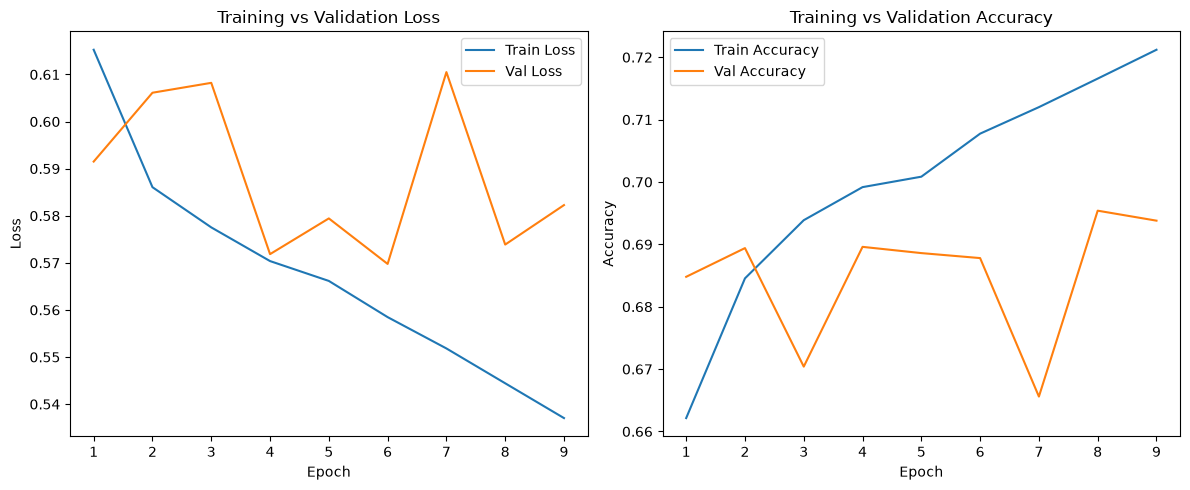

Memory cleaned.
Saved best model state to models/tiny_transformer_imdb_rope.pt
Epoch 01 | train_loss=0.5854 val_loss=0.5929 | train_acc=0.6903 val_acc=0.6900
Saved best model state to models/tiny_transformer_imdb_rope.pt
Epoch 02 | train_loss=0.5638 val_loss=0.5795 | train_acc=0.7040 val_acc=0.7008
Saved best model state to models/tiny_transformer_imdb_rope.pt
Epoch 03 | train_loss=0.5489 val_loss=0.5630 | train_acc=0.7138 val_acc=0.7072
Saved best model state to models/tiny_transformer_imdb_rope.pt
Epoch 04 | train_loss=0.5395 val_loss=0.5506 | train_acc=0.7199 val_acc=0.7080
Epoch 05 | train_loss=0.5268 val_loss=0.5522 | train_acc=0.7275 val_acc=0.7082
Saved best model state to models/tiny_transformer_imdb_rope.pt
Epoch 06 | train_loss=0.5140 val_loss=0.5421 | train_acc=0.7345 val_acc=0.7118
Epoch 07 | train_loss=0.5000 val_loss=0.5629 | train_acc=0.7482 val_acc=0.7192
Saved best model state to models/tiny_transformer_imdb_rope.pt
Epoch 08 | train_loss=0.4857 val_loss=0.5418 | train_

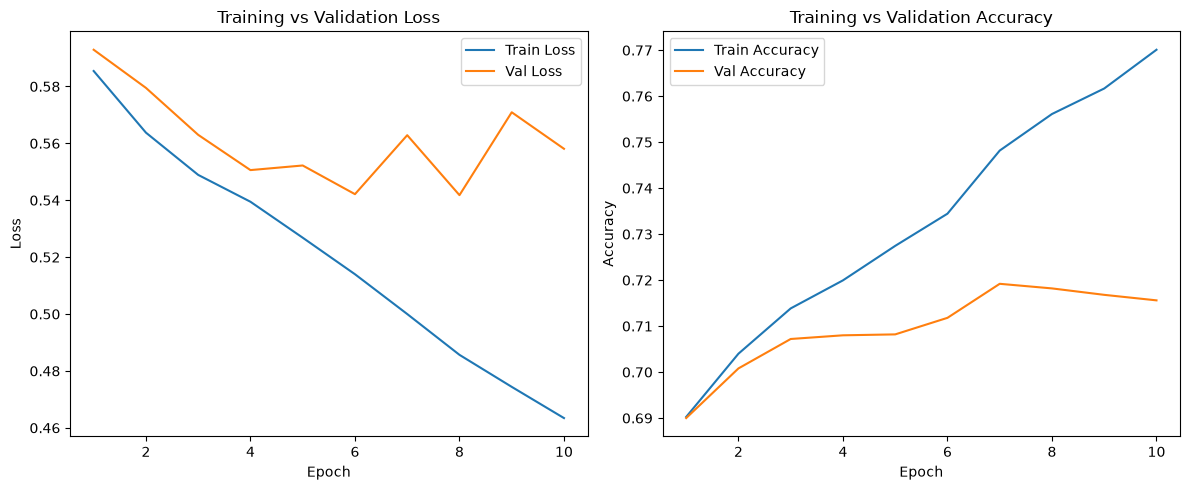

In [14]:
clean_memory()
torch.manual_seed(204)
absolute_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=False,
    use_absolute_positions=True,
).to(device)

absolute_model = train_binary_classifier(
    model=absolute_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=10,
    lr=1e-4,
    patience=3,
    save_model_path="./models/tiny_transformer_imdb_absolute.pt",
)

clean_memory()
torch.manual_seed(204)
rope_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=True,
    use_absolute_positions=False,
).to(device)

rope_model = train_binary_classifier(
    model=rope_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=10,
    lr=1e-4,
    patience=3,
    save_model_path="./models/tiny_transformer_imdb_rope.pt",
)


### Train vs Test Results
After training, we evaluate each model on the train split and the held-out test split. This is not a leaderboard result; it is a quick check for fit and generalization on the tiny subset.

In [12]:
# Optional: Load pre-trained models to skip training or restore after a kernel restart
absolute_model = TinyTransformerClassifier(**shared_model_kwargs, use_rope=False, use_absolute_positions=True).to(device)
absolute_model.load_state_dict(torch.load("./models/tiny_transformer_imdb_absolute.pt", map_location=device, weights_only=True))

rope_model = TinyTransformerClassifier(**shared_model_kwargs, use_rope=True, use_absolute_positions=False).to(device)
rope_model.load_state_dict(torch.load("./models/tiny_transformer_imdb_rope.pt", map_location=device, weights_only=True))


<All keys matched successfully>

absolute | train_loss=0.5359 train_acc=0.7251 | test_loss=0.5570 test_acc=0.7070
    rope | train_loss=0.4572 train_acc=0.7777 | test_loss=0.5252 test_acc=0.7282


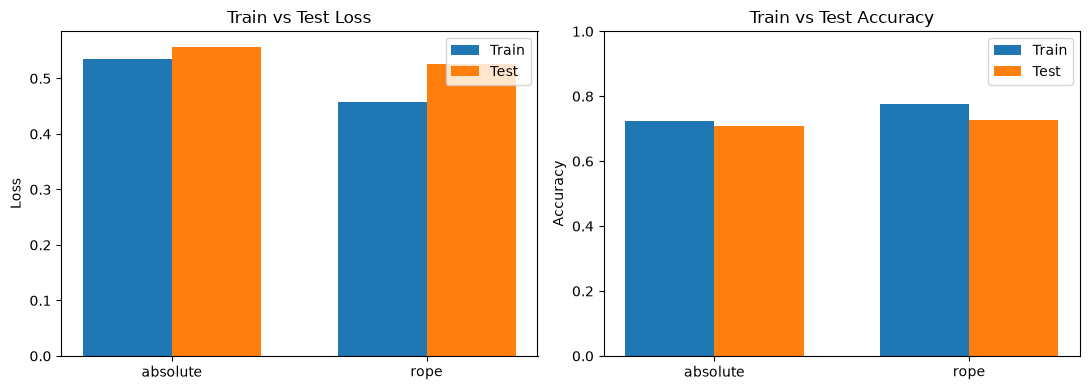

In [13]:
criterion = nn.BCEWithLogitsLoss()
results = {}

for model_name, model in {
    "absolute": absolute_model,
    "rope": rope_model,
}.items():
    train_loss, train_acc = evaluate_binary_classifier(model, train_loader, criterion, device)
    test_loss, test_acc = evaluate_binary_classifier(model, test_loader, criterion, device)
    results[model_name] = {
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
    }
    print(
        f"{model_name:>8} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
    )

model_names = list(results.keys())
x = torch.arange(len(model_names)).numpy()
bar_width = 0.35

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.bar(x - bar_width / 2, [results[name]["train_loss"] for name in model_names], width=bar_width, label="Train")
plt.bar(x + bar_width / 2, [results[name]["test_loss"] for name in model_names], width=bar_width, label="Test")
plt.xticks(x, model_names)
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(x - bar_width / 2, [results[name]["train_acc"] for name in model_names], width=bar_width, label="Train")
plt.bar(x + bar_width / 2, [results[name]["test_acc"] for name in model_names], width=bar_width, label="Test")
plt.xticks(x, model_names)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Train vs Test Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### Hard Review Probe
The full IMDb test split gives a broad accuracy signal, but it does not isolate specific reasoning patterns. This tiny handwritten probe checks examples where order and context should matter more than isolated sentiment words: negation, contrast, faint praise, and sentiment reversal. It is a behavioral probe, not a formal benchmark.

Hard review probe: label 1 = positive, label 0 = negative
[negation] label=0 | The film is not good; the few funny moments cannot save the dull story.
absolute: pred=0 prob=0.432
rope: pred=0 prob=0.051

[negation] label=1 | The film is not bad at all, with a surprisingly warm final act.
absolute: pred=0 prob=0.015
rope: pred=0 prob=0.005

[contrast] label=0 | The acting is excellent, but the movie becomes tedious and empty by the end.
absolute: pred=1 prob=0.555
rope: pred=1 prob=0.995

[contrast] label=1 | The opening is clumsy, but the story grows into a moving and memorable drama.
absolute: pred=1 prob=0.785
rope: pred=1 prob=0.922

[faint_praise] label=0 | It is beautifully shot and professionally acted, yet somehow lifeless, cold, and forgettable.
absolute: pred=1 prob=0.991
rope: pred=1 prob=0.951

[sentiment_shift] label=1 | I expected to hate it after the first act, but by the finale I was completely won over.
absolute: pred=1 prob=0.562
rope: pred=1 prob=0.726



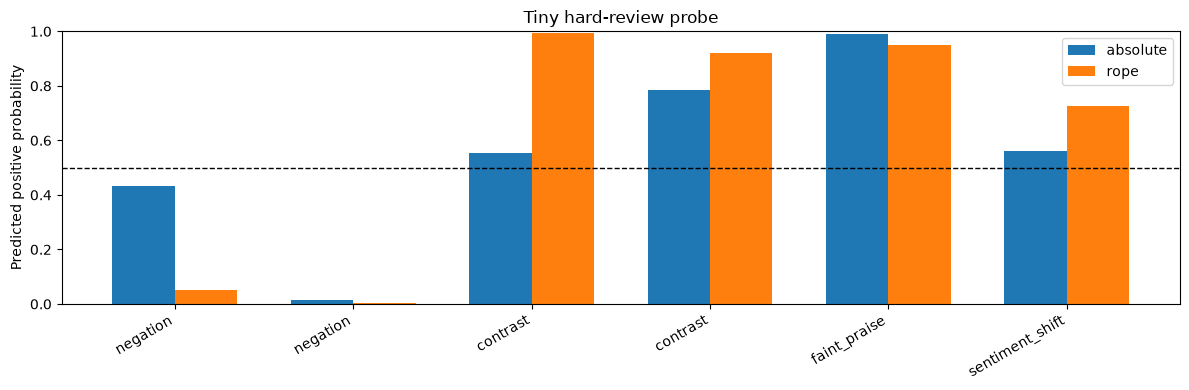

In [14]:
hard_reviews = [
    {
        "group": "negation",
        "text": "The film is not good; the few funny moments cannot save the dull story.",
        "label": 0,
    },
    {
        "group": "negation",
        "text": "The film is not bad at all, with a surprisingly warm final act.",
        "label": 1,
    },
    {
        "group": "contrast",
        "text": "The acting is excellent, but the movie becomes tedious and empty by the end.",
        "label": 0,
    },
    {
        "group": "contrast",
        "text": "The opening is clumsy, but the story grows into a moving and memorable drama.",
        "label": 1,
    },
    {
        "group": "faint_praise",
        "text": "It is beautifully shot and professionally acted, yet somehow lifeless, cold, and forgettable.",
        "label": 0,
    },
    {
        "group": "sentiment_shift",
        "text": "I expected to hate it after the first act, but by the finale I was completely won over.",
        "label": 1,
    },
]

hard_ids, hard_masks, _ = bpe_batch_encode(
    [item["text"] for item in hard_reviews],
    bpe_merges=bpe_merges,
    bpe_vocab=bpe_vocab,
    max_len=max_seq_len,
)
hard_ids = hard_ids.to(device)
hard_masks = hard_masks.to(device)

probe_results = {}
for model_name, model in {
    "absolute": absolute_model,
    "rope": rope_model,
}.items():
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(hard_ids, hard_masks)).squeeze(-1).detach().cpu()
    preds = (probs > 0.5).long()
    probe_results[model_name] = {"probs": probs, "preds": preds}

print("Hard review probe: label 1 = positive, label 0 = negative")
for idx, item in enumerate(hard_reviews):
    row = [f"[{item['group']}] label={item['label']} | {item['text']}"]
    for model_name in probe_results:
        prob = probe_results[model_name]["probs"][idx].item()
        pred = int(probe_results[model_name]["preds"][idx].item())
        row.append(f"{model_name}: pred={pred} prob={prob:.3f}")
    print("\n".join(row))
    print()

model_names = list(probe_results.keys())
x = torch.arange(len(hard_reviews)).numpy()
bar_width = 0.35

plt.figure(figsize=(12, 4))
for offset, model_name in zip([-bar_width / 2, bar_width / 2], model_names):
    plt.bar(
        x + offset,
        probe_results[model_name]["probs"].numpy(),
        width=bar_width,
        label=model_name,
    )
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xticks(x, [item["group"] for item in hard_reviews], rotation=30, ha="right")
plt.ylabel("Predicted positive probability")
plt.ylim(0, 1)
plt.title("Tiny hard-review probe")
plt.legend()
plt.tight_layout()
plt.show()


## Wrap-Up
At this point we have:
- a reusable multi-head attention module
- rotary and sinusoidal positional encoding utilities
- a Transformer block with residual connections
- a cross-attention extension with rectangular query-to-context attention maps
- attention heatmaps for visual inspection
- two compact IMDb Transformer encoder classifiers initialized from the trained `DAN` embeddings
- train, validation, test, and handwritten hard-review probes for comparing absolute positions with `RoPE`

In this run, the mini Transformer classifiers did not outperform the Week 5 TextCNN baseline. The CNN remained stronger on regular IMDb accuracy, likely because IMDb sentiment often rewards local phrase detection, and convolution plus max pooling is a strong fit for phrases such as `not bad`, `waste of time`, or `surprisingly moving`.

`RoPE` positional encoding also performed better than absolute sinusoidal positional encoding in this setup. That does not mean absolute is worse in general; it means that for this small encoder classifier, trained from `DAN` embeddings on IMDb-length sequences, relative position information from `RoPE` was easier or more useful for the model to exploit.

The hard-review probe showed a shared limitation across the models rather than a Transformer-only failure. None of the models handled all of the handcrafted examples well, and the Transformer variants were especially weak on negative labels outside simple negation. One plausible reason is data coverage: even a balanced 50/50 IMDb dataset may not contain enough targeted examples of faint praise, contrastive reversal, sarcasm-like wording, or late sentiment shifts for the models to learn those behaviors reliably. With around `0.71-0.73` accuracy, there is still a substantial error region, and the handcrafted probe may live inside it.

This mini Transformer classifier is intentionally simple: a small encoder stack, mean pooling, limited tuning, and `DAN`-initialized token embeddings rather than a fully pretrained contextual encoder. The architecture can use order and context, but that capacity does not guarantee robust sentiment reasoning without the right training signal, model capacity, pooling strategy, and optimization recipe.